# 02 — User Reasoning Knowledge Evaluation

Loads a pre-generated evaluation report (`reasoning_eval_report.json`) produced by `scripts/eval_reasoning.py` and visualizes the results.

**Sections:**
1. Setup & Prerequisites
2. Structural Analysis (coverage, completeness, discriminability, token budget)
3. LLM-as-Judge Analysis (5 dimensions)
4. Go/No-Go Summary

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path('.').absolute().parent
sys.path.insert(0, str(PROJECT_ROOT))

### Prerequisites

Run these scripts **before** this notebook:

```bash
# 1. Preprocess (skip if already done)
python scripts/preprocess.py \
    --raw-dir data/h-and-m-personalized-fashion-recommendations \
    --output-dir data/processed

# 2. Extract factual knowledge (skip if already done)
python scripts/extract_factual_knowledge.py \
    --data-dir data/processed \
    --images-dir data/h-and-m-personalized-fashion-recommendations/images \
    --output-dir data/knowledge/factual \
    --batch-api

# 3. Extract reasoning knowledge (skip if already done)
python scripts/extract_reasoning_knowledge.py \
    --data-dir data/processed \
    --fk-dir data/knowledge/factual \
    --output-dir data/knowledge/reasoning \
    --batch-api

# 4. Run evaluation (generates this notebook's input)
python scripts/eval_reasoning.py \
    --data-dir data/processed \
    --reasoning-dir data/knowledge/reasoning \
    --knowledge-dir data/knowledge/factual \
    --output-dir results/eval/reasoning \
    --skip-judge

# Or with LLM-as-Judge:
python scripts/eval_reasoning.py \
    --data-dir data/processed \
    --reasoning-dir data/knowledge/reasoning \
    --knowledge-dir data/knowledge/factual \
    --output-dir results/eval/reasoning \
    --sample-size 50
```

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

# Load report
REPORT_PATH = PROJECT_ROOT / "results" / "eval" / "reasoning" / "reasoning_eval_report.json"
OUTPUT_DIR = PROJECT_ROOT / "results" / "eval" / "reasoning"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with open(REPORT_PATH) as f:
    report = json.load(f)

print(f"Report timestamp: {report.get('timestamp', 'N/A')}")
print(f"Sections: {list(report.keys())}")

Report timestamp: 2026-02-23T07:39:47.994223+00:00
Sections: ['completeness', 'discriminability', 'coverage', 'token_budget', 'judge', 'timestamp']


## 2. Structural Analysis

### 2.1 Coverage

In [3]:
cov = report["coverage"]
print(f"Overall coverage: {cov['overall_coverage']:.1%}")
print(f"Items evaluated: {cov['n_items']:,}")

for f, v in cov["field_coverage"].items():
    status = "OK" if v >= 0.9 else "LOW"
    print(f"  {f:.<30s} {v:.1%}  [{status}]")

Overall coverage: 55.0%
Items evaluated: 1,298,206
  reasoning_text................ 32.5%  [LOW]
  reasoning_json................ 32.5%  [LOW]
  n_purchases................... 100.0%  [OK]


**Interpretation:** Coverage checks that `reasoning_text`, `reasoning_json`, and `n_purchases` columns are populated. Values >= 90% indicate successful reasoning knowledge generation across the user base.

### 2.2 Completeness (9-Field)

Overall completeness: 32.5%
Generic profiles: 131
Short profiles: 876,590


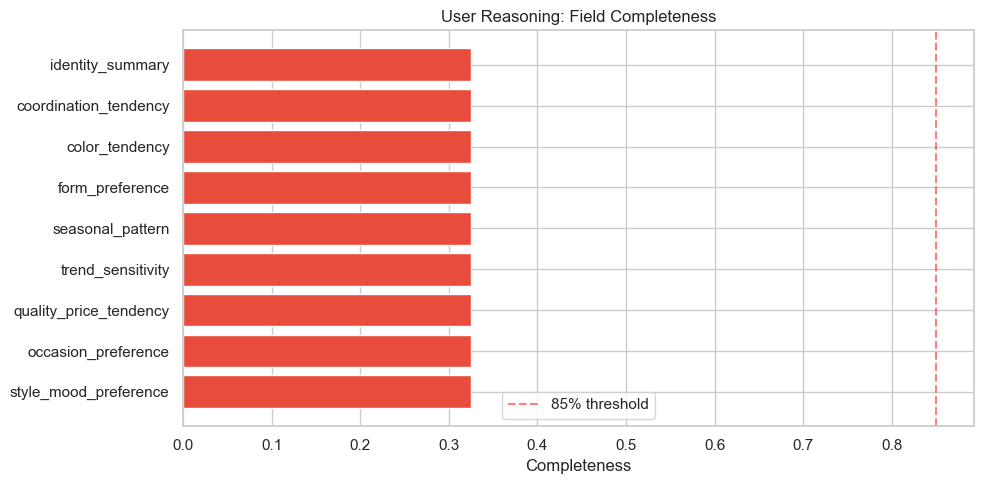

In [4]:
comp = report["completeness"]
print(f"Overall completeness: {comp['overall_completeness']:.1%}")
print(f"Generic profiles: {comp['n_generic']:,}")
print(f"Short profiles: {comp['n_short']:,}")

fig, ax = plt.subplots(figsize=(10, 5))
fields = list(comp["field_completeness"].keys())
values = list(comp["field_completeness"].values())
colors = ["#2ecc71" if v >= 0.85 else "#e74c3c" for v in values]
ax.barh(fields, values, color=colors)
ax.axvline(0.85, color="red", linestyle="--", alpha=0.5, label="85% threshold")
ax.set_xlabel("Completeness")
ax.set_title("User Reasoning: Field Completeness")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_completeness.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** Completeness measures the 9 reasoning profile fields (style_mood, occasion_preference, quality_price_tendency, trend_sensitivity, color_palette_preference, form_preference, texture_material_preference, seasonal_behavior, identity_summary). Generic profiles contain boilerplate markers (Unknown, N/A); short profiles have very few tokens.

### 2.3 Discriminability

In [5]:
disc = report["discriminability"]
print(f"Mean pairwise similarity: {disc['mean_pairwise_sim']:.3f}")
print(f"Median pairwise similarity: {disc['median_pairwise_sim']:.3f}")
print(f"Mean unique trigrams: {disc['mean_trigrams']:.0f}")

if disc.get("per_field_unique_ratio"):
    print("\nPer-field unique ratio:")
    for f, r in disc["per_field_unique_ratio"].items():
        print(f"  {f:.<30s} {r:.3f}")

Mean pairwise similarity: 0.489
Median pairwise similarity: 0.481
Mean unique trigrams: 42


**Interpretation:** Discriminability measures how distinct profiles are from each other. Mean pairwise cosine similarity < 0.3 is excellent (profiles are well-differentiated). High unique trigram counts indicate lexical diversity. Values > 0.6 would signal that profiles are too similar (cookie-cutter outputs).

### 2.4 Token Budget

In [6]:
tb = report["token_budget"]
token_df = pd.DataFrame([{
    "Metric": "Mean tokens",
    "Value": f"{tb['mean_tokens']:.0f}",
}, {
    "Metric": "Median tokens",
    "Value": f"{tb['median_tokens']:.0f}",
}, {
    "Metric": "P95 tokens",
    "Value": f"{tb['p95_tokens']:.0f}",
}, {
    "Metric": "P99 tokens",
    "Value": f"{tb['p99_tokens']:.0f}",
}, {
    "Metric": "Max tokens",
    "Value": str(tb["max_tokens"]),
}, {
    "Metric": "Over budget",
    "Value": f"{tb['n_over_budget']:,} ({tb['pct_over_budget']:.1%})",
}, {
    "Metric": "Budget limit",
    "Value": str(tb["budget_limit"]),
}])
display(token_df)

,Metric,Value
0,Mean tokens,57
1,Median tokens,57
2,P95 tokens,62
3,P99 tokens,62
4,Max tokens,322
5,Over budget,0 (0.0%)
6,Budget limit,512


**Interpretation:** Token budget checks that reasoning text fits within the BGE-base encoder's 512-token context window. P99 should be under 512 for safe encoding without truncation.

## 3. LLM-as-Judge Analysis

This section visualizes LLM-as-Judge results if they were included in the report (i.e., `scripts/eval_reasoning.py` was run **without** `--skip-judge`).

In [7]:
judge = report.get("judge")
if judge is None:
    print("LLM-as-Judge was not included in this report.")
    print("Re-run: python scripts/eval_reasoning.py ... (without --skip-judge)")

Evaluated: 200
Overall mean: 4.48
Pass rate: 100.0%


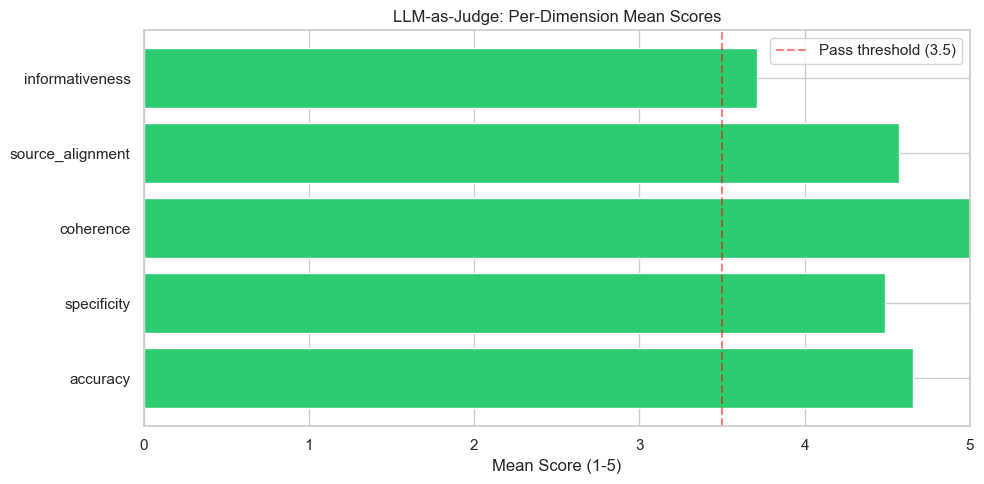

In [8]:
if judge is not None:
    print(f"Evaluated: {judge['n_evaluated']}")
    print(f"Overall mean: {judge['overall_mean']:.2f}")
    print(f"Pass rate: {judge['pass_rate']:.1%}")

    # Per-dimension mean bar chart
    dim_means = judge["per_dimension_mean"]
    fig, ax = plt.subplots(figsize=(10, 5))
    dims = list(dim_means.keys())
    means = list(dim_means.values())
    colors_bar = ["#2ecc71" if m >= 3.5 else "#e74c3c" for m in means]
    ax.barh(dims, means, color=colors_bar)
    ax.axvline(3.5, color="red", linestyle="--", alpha=0.5, label="Pass threshold (3.5)")
    ax.set_xlabel("Mean Score (1-5)")
    ax.set_title("LLM-as-Judge: Per-Dimension Mean Scores")
    ax.set_xlim(0, 5)
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "02_judge_scores.png", dpi=150, bbox_inches="tight")
    plt.show()

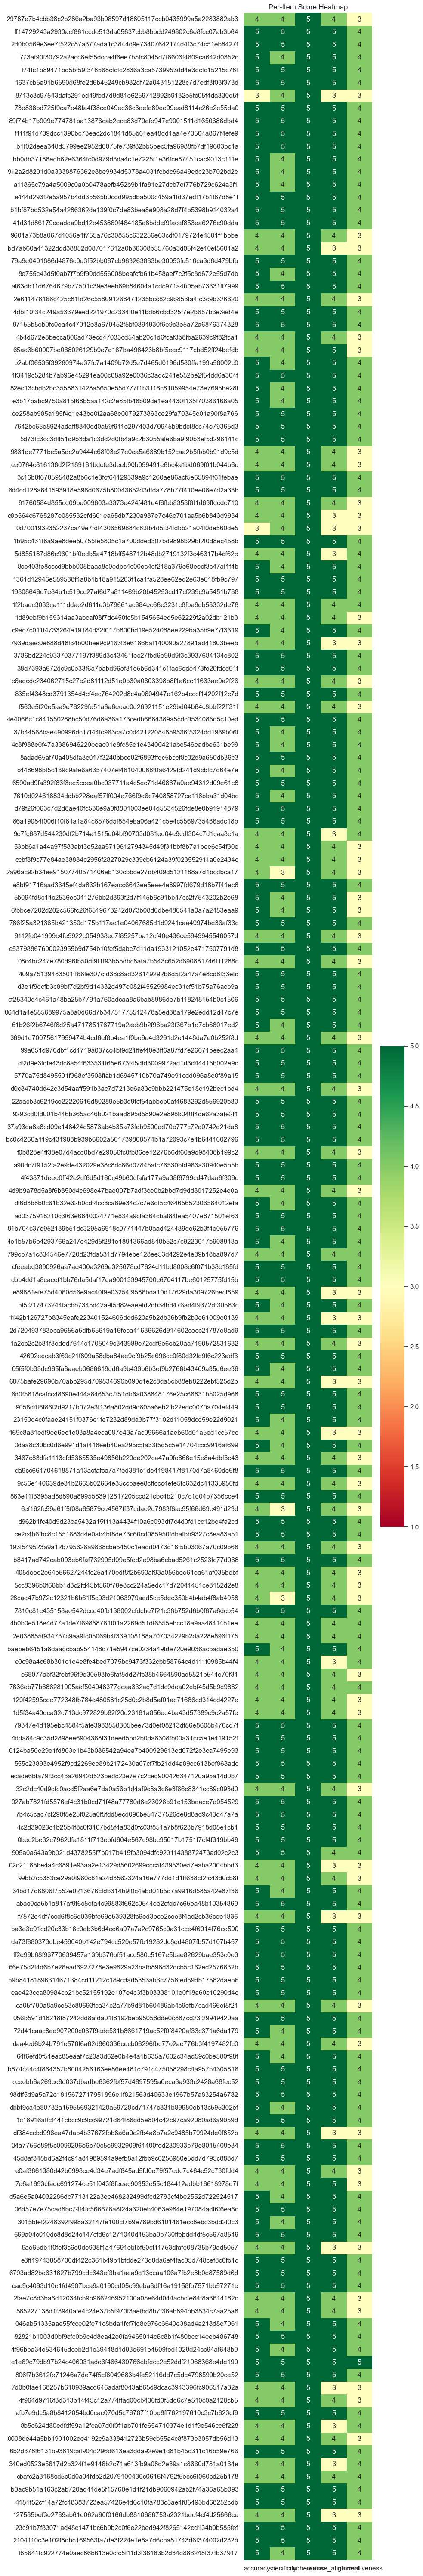

In [9]:
if judge is not None:
    results = judge["results"]
    dim_names = list(judge["per_dimension_mean"].keys())

    # Build score matrix (items x dimensions)
    item_ids = [r["item_id"] for r in results]
    score_matrix = np.array([[r["scores"][d] for d in dim_names] for r in results])

    fig, ax = plt.subplots(figsize=(10, max(6, len(item_ids) * 0.3)))
    sns.heatmap(
        score_matrix,
        xticklabels=dim_names,
        yticklabels=item_ids,
        annot=True,
        fmt="d",
        cmap="RdYlGn",
        vmin=1,
        vmax=5,
        ax=ax,
    )
    ax.set_title("Per-Item Score Heatmap")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "02_judge_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()

In [10]:
if judge is not None:
    # Items with any dimension score <= 2
    low_scorers = []
    for r in results:
        low_dims = [d for d, s in r["scores"].items() if s <= 2]
        if low_dims:
            for d in low_dims:
                low_scorers.append({
                    "item_id": r["item_id"],
                    "dimension": d,
                    "score": r["scores"][d],
                    "justification": r["justifications"].get(d, ""),
                })

    if low_scorers:
        low_df = pd.DataFrame(low_scorers).sort_values("score")
        print(f"Low-scoring profiles (score <= 2): {len(low_df)}")
        display(low_df)
    else:
        print("No profiles scored <= 2 on any dimension.")

No profiles scored <= 2 on any dimension.


/var/folders/qj/c_b2zj_s1qzfgrvbf49cn16h0000gn/T/ipykernel_24403/1425802196.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=score_df, x="dimension", y="score", ax=ax, palette="Set2")


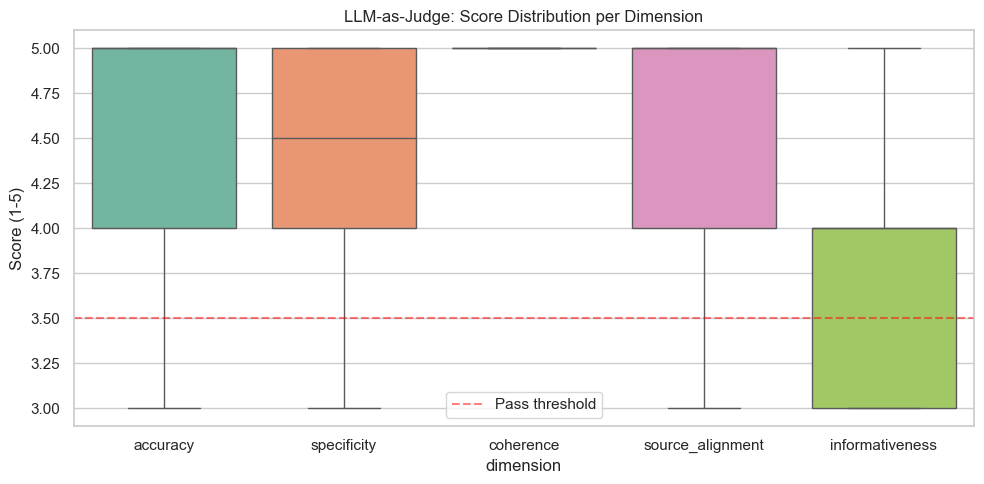

In [11]:
if judge is not None:
    score_data = []
    for r in results:
        for dim in dim_names:
            score_data.append({"dimension": dim, "score": r["scores"][dim]})
    score_df = pd.DataFrame(score_data)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=score_df, x="dimension", y="score", ax=ax, palette="Set2")
    ax.axhline(3.5, color="red", linestyle="--", alpha=0.5, label="Pass threshold")
    ax.set_ylabel("Score (1-5)")
    ax.set_title("LLM-as-Judge: Score Distribution per Dimension")
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "02_judge_boxplot.png", dpi=150, bbox_inches="tight")
    plt.show()

**Interpretation:** The LLM-as-Judge evaluates 5 dimensions on a 1-5 scale:
- **Accuracy**: Does reasoning reflect actual purchase data?
- **Specificity**: Is reasoning specific to this user, not boilerplate?
- **Coherence**: Do 9 fields form a coherent fashion identity?
- **Source Alignment**: Does reasoning match source data (price quintile, L1/L2/L3)?
- **Informativeness**: Are preferences specific enough for recommendation?

Pass threshold is 3.5 per dimension. Profiles scoring <= 2 need manual review.

## 4. Go/No-Go Summary

In [12]:
from src.eval_prompt.report import REASONING_CRITERIA

# Build Go/No-Go table from report data
def resolve_value(data, path):
    """Resolve a dotted path in a nested dict."""
    for part in path.split("."):
        if data is None or not isinstance(data, dict):
            return None
        data = data.get(part)
    return data

go_no_go_rows = []
all_passed = True

for name, (path, threshold, op) in REASONING_CRITERIA.items():
    value = resolve_value(report, path)

    if value is None:
        go_no_go_rows.append({
            "Criterion": name,
            "Status": "SKIP",
            "Value": "N/A",
            "Threshold": f"{threshold}",
            "Detail": f"{path} not available (judge disabled?)",
        })
        continue

    if op == ">=":
        passed = float(value) >= threshold
        detail = f"{path}={value:.3f} >= {threshold:.3f}"
    elif op == "<=":
        passed = float(value) <= threshold
        detail = f"{path}={value:.3f} <= {threshold:.3f}"
    elif op == "rate_<=":
        n_items = resolve_value(report, "coverage.n_items") or 1
        if "completeness" in path:
            n_items = resolve_value(report, "completeness.n_short") or n_items
        rate = float(value) / max(float(n_items), 1)
        passed = rate <= threshold
        detail = f"{path}={value} (rate={rate:.3f}) <= {threshold:.3f}"
    else:
        passed = True
        detail = f"Unknown operator: {op}"

    status = "PASS" if passed else "FAIL"
    if not passed and "SKIP" not in detail:
        all_passed = False

    go_no_go_rows.append({
        "Criterion": name,
        "Status": status,
        "Value": f"{value}" if isinstance(value, (int, str)) else f"{value:.4f}",
        "Threshold": f"{threshold}",
        "Detail": detail,
    })

go_df = pd.DataFrame(go_no_go_rows)
display(go_df)

overall = "GO" if all_passed else "NO-GO"
print(f"\nOverall: {overall}")

,Criterion,Status,Value,Threshold,Detail
0,completeness,FAIL,0.3247,0.85,completeness.overall_completeness=0.325 >= 0.850
1,generic_rate,PASS,131,0.1,completeness.n_generic=131 (rate=0.000) <= 0.100
2,discriminability,PASS,0.4892,0.6,discriminability.mean_pairwise_sim=0.489 <= 0.600
3,token_budget,PASS,0.0000,0.05,token_budget.pct_over_budget=0.000 <= 0.050
4,judge_overall,PASS,4.4850,3.5,judge.overall_mean=4.485 >= 3.500
5,judge_pass_rate,PASS,1.0000,0.7,judge.pass_rate=1.000 >= 0.700



Overall: NO-GO
